In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

In [7]:
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)

# Add noisy features
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X = np.concatenate([X, random_state.randn(n_samples, 200 * n_features)], axis=1)

# Limit to the two first classes, and split into training and test
X_train, X_test, y_train, y_test = train_test_split(
    X[y < 2], y[y < 2], test_size=0.5, random_state=random_state
)

In [40]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron

classifier_linear = make_pipeline(StandardScaler(), Perceptron(random_state=random_state, max_iter=1))
classifier_linear.fit(X_train, y_train)

c:\Users\XUYU0\miniconda3\envs\work\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,steps,"[('standardscaler', ...), ('perceptron', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True


In [41]:
classifier_rbf = make_pipeline(StandardScaler(), SVC(kernel="sigmoid", random_state=random_state))
classifier_rbf.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'


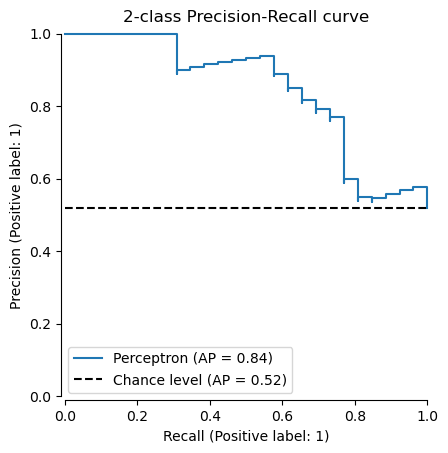

In [42]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    classifier_linear, X_test, y_test, name="Perceptron", plot_chance_level=True, despine=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")
plt.show()

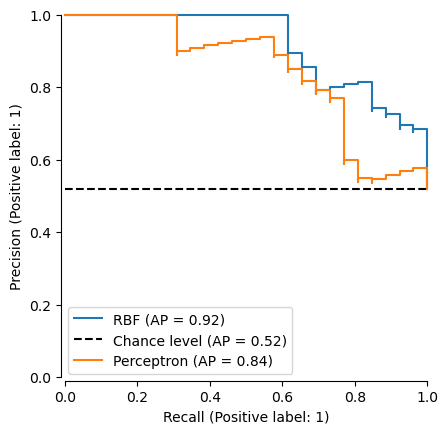

In [43]:
ax = plt.gca()
display_rbf = PrecisionRecallDisplay.from_estimator(
    classifier_rbf, X_test, y_test, name="RBF", plot_chance_level=True, despine=True, ax=ax
)
display.plot(ax=ax)
plt.show()